#Setup

In [2]:
import os

os.environ["KERAS_BACKEND"] = "jax"  # @param ["tensorflow", "jax", "torch"]

import keras
from keras import layers
#import tensorflow_ops as ops
#from keras import ops

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tqdm
import seaborn as sns

from tensorflow import keras
from keras import Input, Model, Sequential
from tensorflow.keras.regularizers import l2
from keras.layers import Dense, Flatten, InputLayer, Reshape, BatchNormalization, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.utils import plot_model

%matplotlib inline

In [3]:

from keras.preprocessing.image import ImageDataGenerator
train_data = ImageDataGenerator().flow_from_directory(directory="/content/drive/MyDrive/Jahanzaib Thesis/dataset/training",
                              target_size=(224,224), batch_size= 4673)

#val_data = ImageDataGenerator().flow_from_directory(directory="/content/drive/MyDrive/Aqsa Research Thesis/dataset/validation",
 #                             target_size=(224,224), batch_size=995)

#test_data = ImageDataGenerator().flow_from_directory(directory="/content/drive/MyDrive/Aqsa Research Thesis/dataset/test",
 #                             target_size=(224,224), batch_size=1006)


Found 4815 images belonging to 2 classes.


In [4]:
imgs, labels = next(train_data)

In [5]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(imgs, labels, test_size=0.2, random_state=42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(3738, 224, 224, 3)
(935, 224, 224, 3)
(3738, 2)
(935, 2)


#Configure the hyperparameters


In [15]:
learning_rate = 0.001
weight_decay = 0.0001
batch_size = 32
num_epochs = 10  # For real training, use num_epochs=100. 10 is a test value
image_size = 224  # We'll resize input images to this size
patch_size = 14  # Size of the patches to be extract from the input images
num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 4
transformer_units = [
    projection_dim * 2,
    projection_dim,
]  # Size of the transformer layers
transformer_layers = 8
mlp_head_units = [
    2048,
    1024,
]  # Size of the dense layers of the final classifier

input_shape= (224,224,3)

In [16]:
data_augmentation = keras.Sequential(
    [
        layers.Normalization(),
        layers.Resizing(image_size, image_size),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    ],
    name="data_augmentation",
)
# Compute the mean and the variance of the training data for normalization.

data_augmentation.layers[0].adapt(x_train)
data_augmentation.build(x_train.shape)

In [17]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

In [18]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super(Patches, self).__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

Image size: 224 X 224
Patch size: 14 X 14
Patches per image: 256
Elements per patch: 588


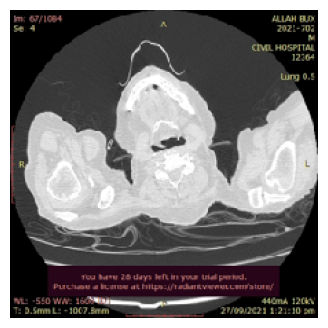

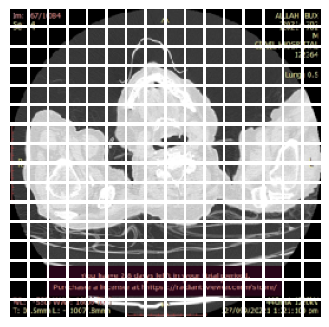

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
image = x_train[np.random.choice(range(x_train.shape[0]))]
plt.imshow(image.astype("uint8"))
plt.axis("off")

resized_image = tf.image.resize(
    tf.convert_to_tensor([image]), size=(image_size, image_size)
)
patches = Patches(patch_size)(resized_image)
print(f"Image size: {image_size} X {image_size}")
print(f"Patch size: {patch_size} X {patch_size}")
print(f"Patches per image: {patches.shape[1]}")
print(f"Elements per patch: {patches.shape[-1]}")

n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(4, 4))
for i, patch in enumerate(patches[0]):
    ax = plt.subplot(n, n, i + 1)
    patch_img = tf.reshape(patch, (patch_size, patch_size, 3))
    plt.imshow(patch_img.numpy().astype("uint8"))
    plt.axis("off")

In [21]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super(PatchEncoder, self).__init__(**kwargs)
        self.num_patches = num_patches
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(num_patches, projection_dim)

    def call(self, patch):
        positions = tf.expand_dims(tf.range(0, self.num_patches, 1), axis=0)
        projected_patches = self.projection(patch)
        encoded = projected_patches + self.position_embedding(positions)
        return encoded

In [22]:
def create_vit_classifier():
    inputs = keras.Input(shape=input_shape)
    # Augment data.
    augmented = data_augmentation(inputs)
    # Create patches.
    patches = Patches(patch_size)(augmented)
    # Encode patches.
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    # Create multiple layers of the Transformer block.
    for _ in range(transformer_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP.
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])

    # Create a [batch_size, projection_dim] tensor.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.25)(representation)
    # Add MLP.
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.25)
    # Classify outputs.
    logits = layers.Dense(2, activation="softmax")(features)
    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=logits)
    return model

In [23]:
def run_experiment(model):
    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=weight_decay
    )

    model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])

    #model.compile(
    #    optimizer=optimizer,
    #    loss=keras.losses.BinaryCrossentropy(from_logits=True),
    #    metrics=[
    #        keras.metrics.BinaryCrossentropy(name="binary_accuracy"),
  #          keras.metrics.BinaryCrossentropy(5, name="top-5-accuracy"),
    #    ],
   # )




    history = model.fit(
        x=x_train,
        y=y_train,
        batch_size=batch_size,
        epochs=num_epochs,
        validation_data= (x_test, y_test),
  #      callbacks=[checkpoint_callback],
  )

 #   model.load_weights('/content/drive/MyDrive/Aqsa Research Thesis/codes/lungsinceptionv3.keras')
 #   _, accuracy, top_5_accuracy = model.evaluate(test_data, test_labels)
 #   print(f"Test accuracy: {round(accuracy * 100, 2)}%")
  #  print(f"Test top 5 accuracy: {round(top_5_accuracy * 100, 2)}%")

    return history


vit_classifier = create_vit_classifier()
history = run_experiment(vit_classifier)




Epoch 1/10
117/117 [==============================] - 34s 80ms/step - loss: 0.8755 - accuracy: 0.8309 - val_loss: 0.2282 - val_accuracy: 0.9209
Epoch 2/10
117/117 [==============================] - 7s 61ms/step - loss: 0.2288 - accuracy: 0.9013 - val_loss: 0.1121 - val_accuracy: 0.9380
Epoch 3/10
117/117 [==============================] - 7s 63ms/step - loss: 0.1584 - accuracy: 0.9371 - val_loss: 0.0709 - val_accuracy: 0.9711
Epoch 4/10
117/117 [==============================] - 8s 64ms/step - loss: 0.1118 - accuracy: 0.9559 - val_loss: 0.0410 - val_accuracy: 0.9861
Epoch 5/10
117/117 [==============================] - 7s 61ms/step - loss: 0.0829 - accuracy: 0.9650 - val_loss: 0.0220 - val_accuracy: 0.9947
Epoch 6/10
117/117 [==============================] - 7s 61ms/step - loss: 0.0971 - accuracy: 0.9674 - val_loss: 0.0163 - val_accuracy: 1.0000
Epoch 7/10
117/117 [==============================] - 7s 62ms/step - loss: 0.0755 - accuracy: 0.9700 - val_loss: 0.0246 - val_accuracy: 0.996

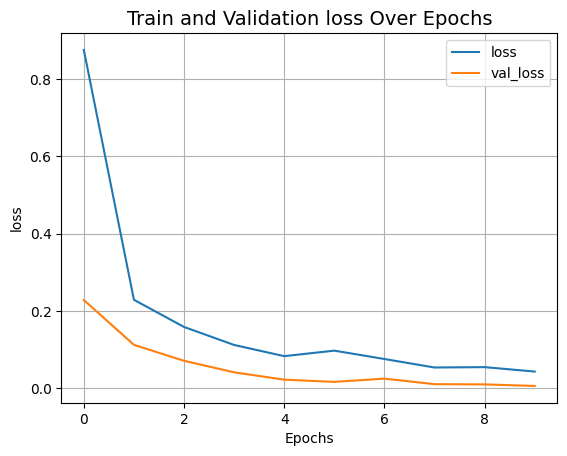

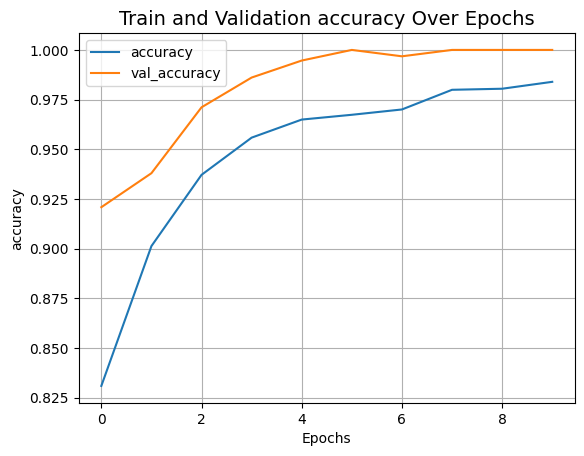

In [24]:
def plot_result(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()


plot_result("loss")
plot_result("accuracy")

In [25]:
import os
os.getcwd()

'/content'

In [26]:
%cd /content/drive/MyDrive/Jahanzaib Thesis

/content/drive/MyDrive/Jahanzaib Thesis


In [27]:
vit_classifier.save('selfatenttion.keras')

In [28]:
from keras.preprocessing.image import ImageDataGenerator
val_data = ImageDataGenerator().flow_from_directory(directory="/content/drive/MyDrive/Jahanzaib Thesis/dataset/testing",
                             target_size=(224,224), batch_size=820)

Found 820 images belonging to 2 classes.


In [29]:
imgs, labels = next(val_data)

In [30]:
vit_classifier.evaluate( imgs, labels)

26/26 [==============================] - 1s 23ms/step - loss: 0.0343 - accuracy: 0.9951


[0.03429782763123512, 0.995121955871582]

In [32]:
import numpy as np
import pandas as pd

y_pred = vit_classifier.predict(imgs, verbose=0)
y_pred.shape

(820, 2)

In [33]:
from sklearn.metrics import confusion_matrix
c_matrix = confusion_matrix(np.argmax(labels, axis=1), np.argmax(y_pred, axis=1))

import seaborn as sns
def confusion_matrix(confusion_matrix, class_names, figsize = (15,7), fontsize=14):
    """Prints a confusion matrix, as returned by sklearn.metrics.confusion_matrix, as a heatmap.

    Arguments
    ---------
    confusion_matrix: numpy.ndarray
        The numpy.ndarray object returned from a call to sklearn.metrics.confusion_matrix.
        Similarly constructed ndarrays can also be used.
    class_names: list
        An ordered list of class names, in the order they index the given confusion matrix.
    figsize: tuple
        A 2-long tuple, the first value determining the horizontal size of the ouputted figure,
        the second determining the vertical size. Defaults to (10,7).
    fontsize: int
        Font size for axes labels. Defaults to 14.
    """
    df_cm = pd.DataFrame(
        confusion_matrix, index=class_names, columns=class_names,
    )
    fig = plt.figure(figsize=figsize)
    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d")
    except ValueError:
        raise ValueError("Confusion matrix values must be integers.")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize=fontsize)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

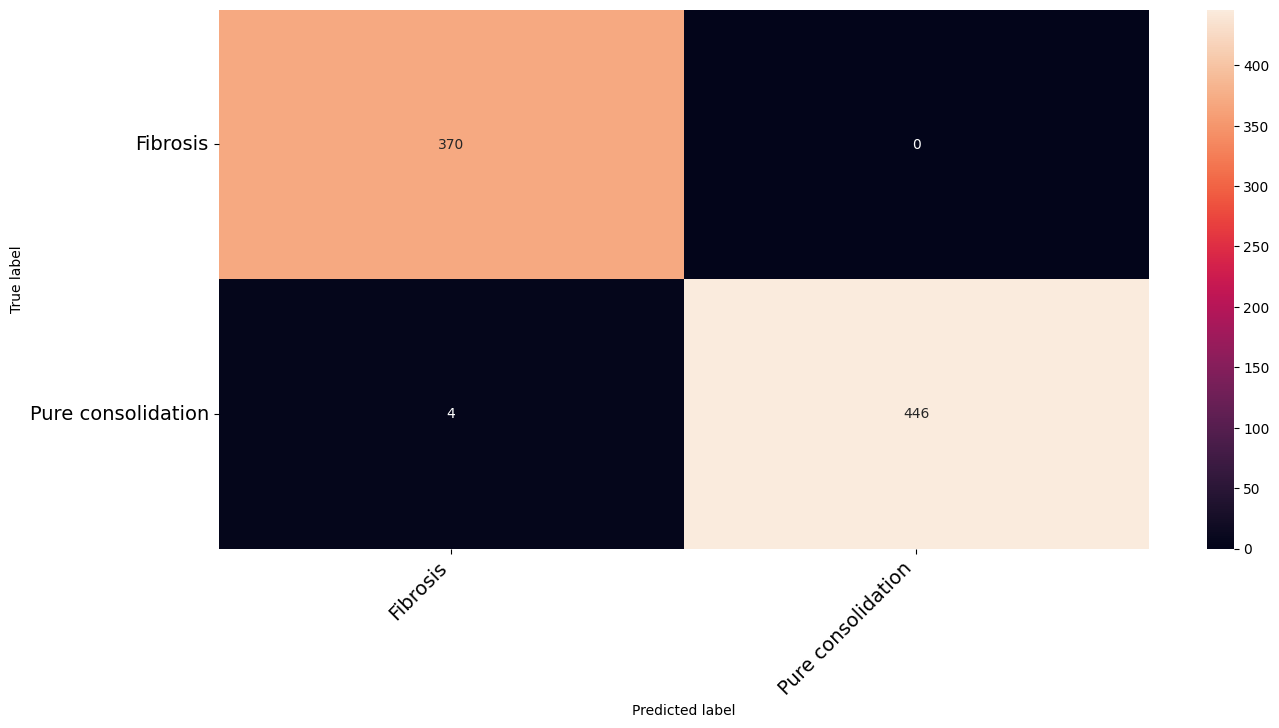

In [34]:
class_names = val_data.class_indices.keys()
confusion_matrix(c_matrix, class_names, figsize = (15,7), fontsize=14)

In [35]:
# From categorical outputs to discrete values

y_pred_ = [np.argmax(y) for y in y_pred]
y_test_ = [np.argmax(y) for y in labels]

from sklearn.metrics import classification_report
print(classification_report(y_test_, y_pred_))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       370
           1       1.00      0.99      1.00       450

    accuracy                           1.00       820
   macro avg       0.99      1.00      1.00       820
weighted avg       1.00      1.00      1.00       820



#